<small><font color=gray>Notebook authors: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a>, <a href="https://www.hse.ru/en/org/persons/223985242/" target="_blank">Alexey Boldyrev</a>, <a href="https://www.hse.ru/en/staff/mekarpov" target="_blank">Maksim Karpov</a>, <a href="https://www.hse.ru/en/staff/sara/" target="_blank">Saraa Ali</a> ©2025 ©2026</font></small><hr style="margin:0;background-color:silver">


**[<font size=6>🔢Recognizer</font>](https://www.kaggle.com/t/f2df677e22a14d0d873375146376ba6e)**. [**Instructions**](https://colab.research.google.com/drive/1owkYjuRGkx050LQnM3b3yTzd0Dr2XbeV) for running Colabs.

We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes.


The data set is similar to [MNIST](https://en.wikipedia.org/wiki/MNIST_database) with each row as a flattened image. However, the digits are not hand-written, but distorted, scaled, shifted, etc.

* `dfYX` contains labels (1 or 7) in the first column and pixel brightness intensities in other columns. Each row's 1024 features can be reshaped to 32x32 images of digits
* `dfX ` contains images (as row vectors) only and no labels. Your trained model will derive the labels for these test images. Then you'll submit these to Kaggle.com

In [18]:
from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json is stored in Google Drive

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
pip install kaggle

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [kaggle]10/12 [kagglesdk]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip -q install --upgrade --force-reinstall --no-deps kaggle > log  # upgrade kaggle package (to avoid a warning)
!mkdir -p ~/.kaggle                                                 # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >log   # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
# !cp kaggle.json ~/.kaggle/kaggle.json > log                       # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                                    # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 26-hse-recognizer-march              # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log                                # download competition dataset as a zip file
!unzip -o *.zip >> log                                              # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show                             # print public leaderboard

zsh:1: command not found: pip
cp: /content/drive/MyDrive/kaggle.json: No such file or directory
chmod: /Users/hgfghgfgfd/.kaggle/kaggle.json: No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
zsh:1: no matches found: *.zip
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [16]:
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import pandas as pd, numpy as np, matplotlib.pyplot as plt, time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
RunTimeLimit, t0 = 120, time.time() # time limit for your model and starting time
np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)

class Timer():
  def __init__(self, lim:'RunTimeLimit'=120): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

pd.set_option('display.max_rows', 100, 'display.max_columns', 100, 'display.max_colwidth', 100, 'display.precision', 2, 'display.max_rows', 4)
dfYX = pd.read_csv('trainYX/trainYX.csv', index_col='id')
dfYX

,y,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,1024
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3,227,233,237,235,233,233,230,226,232,235,241,245,239,229,227,233,232,229,226,227,230,232,232,230,248,235,242,247,238,242,246,231,230,234,237,235,234,234,229,223,229,231,237,242,240,232,231,235,235,...,229,233,219,227,234,237,238,239,237,232,230,224,229,236,232,228,232,234,241,234,230,232,234,233,235,238,241,245,240,237,240,236,235,244,237,244,238,222,221,235,240,234,237,227,233,240,230,223,227,229
1,8,232,250,252,238,228,238,244,241,252,253,251,225,252,252,202,242,242,203,254,254,226,252,254,252,239,242,238,216,244,249,254,240,211,207,229,209,231,244,255,255,246,255,245,210,249,235,187,243,242,...,193,240,242,186,234,249,211,246,255,248,255,255,246,220,215,226,210,218,229,255,255,245,211,237,247,247,252,255,255,227,249,248,198,248,241,201,252,252,225,252,254,253,243,245,240,216,243,247,251,237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4998,3,241,242,243,241,239,238,238,240,242,242,242,242,242,240,239,238,238,236,237,243,246,243,241,242,240,239,239,240,241,242,241,240,238,240,241,240,238,238,239,240,244,244,244,243,241,238,236,234,235,...,217,219,224,228,233,239,244,245,244,242,241,240,239,238,238,237,237,238,241,242,241,238,240,243,241,237,240,237,237,238,236,230,227,229,231,233,236,241,245,246,244,242,240,240,239,238,238,239,239,239
4999,3,248,244,242,246,249,248,248,250,250,247,244,244,247,249,249,248,246,247,248,249,249,249,249,248,251,252,250,245,240,241,247,254,253,248,246,249,250,249,249,252,249,249,249,250,249,248,245,243,246,...,251,246,248,244,244,249,250,248,246,248,253,250,247,245,242,241,245,250,249,247,245,247,249,251,250,248,250,249,236,244,249,245,252,246,252,243,243,252,251,241,244,255,250,247,247,250,249,245,244,246


This test file is missing a column of digit labels, which you need to predict

In [17]:
dfX = pd.read_csv('testX/testX.csv', index_col='id')
dfX

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,...,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,1024
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5000,242,242,242,241,240,239,238,237,235,235,236,235,233,232,231,231,235,234,234,236,239,238,234,230,234,232,230,230,232,235,235,235,240,240,240,240,239,237,236,235,232,233,234,234,234,233,232,230,235,234,...,233,234,234,235,234,232,232,234,238,240,232,234,234,232,233,236,234,230,230,229,229,229,230,231,233,235,233,232,233,234,233,231,232,233,229,233,235,234,233,233,233,233,234,238,238,235,234,236,235,231
5001,243,230,235,224,240,227,238,235,232,211,238,240,229,238,229,228,222,241,231,254,231,224,231,241,236,241,221,224,242,210,222,230,228,231,223,242,231,238,224,227,235,225,244,234,223,240,236,230,233,243,...,219,245,233,255,227,240,234,248,237,222,239,228,241,237,238,243,228,237,252,241,226,248,209,235,237,248,241,222,253,222,246,225,242,240,249,197,233,234,224,203,243,229,226,242,247,252,238,222,235,243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9998,248,247,248,240,228,236,252,255,221,216,255,250,231,226,211,252,255,217,217,244,249,247,230,214,255,253,238,229,239,246,245,248,247,246,251,247,237,244,254,252,253,235,252,255,255,255,240,255,255,232,...,244,255,250,255,243,249,238,252,237,248,244,248,244,250,255,240,229,245,249,246,247,239,229,237,252,254,214,222,246,255,226,227,212,255,255,210,236,230,253,255,204,228,253,255,235,208,236,255,248,245
9999,234,233,233,234,236,237,237,236,234,231,230,233,233,231,232,236,236,234,235,238,242,243,240,237,236,235,234,234,235,236,238,240,235,233,232,233,235,235,234,232,232,229,229,233,233,230,231,234,233,232,...,235,237,237,237,237,237,235,233,231,229,233,235,238,239,237,234,233,233,236,237,236,233,229,228,231,234,237,237,235,233,232,233,235,238,238,239,240,239,236,234,233,234,228,232,236,238,237,235,233,233


Here are the first few digits.

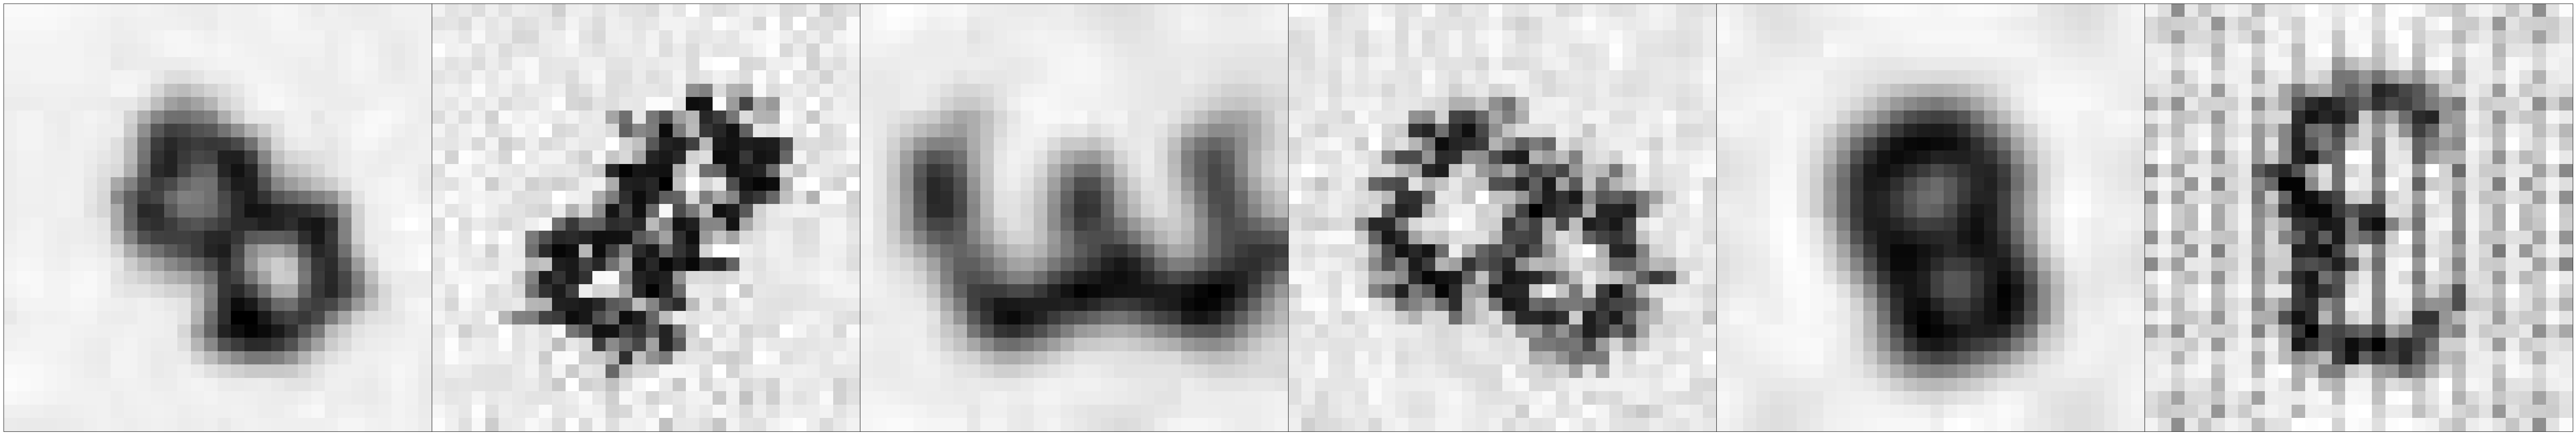

In [18]:
X = dfX.values
n_col, w = 6, 32
_ = plt.figure(figsize=(6*12,12))
for i in range(n_col):
    ax = plt.subplot(1, n_col, i + 1)
    _ = plt.imshow(X[i,].reshape(w,w).astype('float'), cmap='gray')
    _, _ = plt.xticks([]), plt.yticks([]);
_ = plt.tight_layout(pad=0)
_ = plt.show()

In [19]:
tmr = Timer()

⏳ started. You have 120 sec. Good luck!


<hr color=red>

<font size=5>⏳</font> <strong><font color=orange size=5>Your Code, Documentation, Ideas and Timer - All Start Here...</font></strong>

**Student's Section** (between ⏳ symbols): add your code and documentation here.

## **Task 1. Preprocessing Pipeline**

Explain elements of your preprocessing pipeline i.e. feature engineering, subsampling, clustering, dimensionality reduction, etc.
1. Why did you choose these elements? (Something in EDA, prior experience,...? Btw, EDA is not required)
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

**Student's answer:**

1. **augment_shifts** - The function takes each image, transforms it into a 32x32 matrix, and uses np.roll to shift it by 1 left, right, up, and down. Each shift is a new training example with the same label. This yields 25,000 training examples from the original 5,000. The logic is that the model becomes more robust to small positional variations in the digits.
1. **StandardScaler** — pixel normalization.
2. **PCA (50)** — Reduces the dimensionality from 1024 to 50 principal components. Removes noise and speeds up training. 50 components were selected based on the results of 5-fold CV: with an increase (50, 80, 100+) the accuracy drops due to noise, with a decrease (30) the information is lost.
3. **Effectiveness** was assessed using 5-fold Stratified CV accuracy. PCA(50) + StandardScaler yielded a better CV score (0.9536) compared to variants without PCA or with a different number of components.
4. **What else did I try:** Edge features (Sobel filters) and symmetry features both worsened the result (0.93 and 0.94, respectively).

## **Task 2. Modeling Approach**
Explain your modeling approach, i.e. ideas you tried and why you thought they would be helpful.

1. How did these decisions guide you in modeling?
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

**Student's answer:**

1. **SVC with RBF kernel** — selected as the best model for the digit image classification task. The RBF kernel performs well with nonlinear decision boundaries, which is typical for pattern recognition problems. Hyperparameters: C=20, gamma=scale. I also used pseudo-labeling: we first train the initial model on the labeled and augmented training data and then use it to predict the labels and probabilities for test objects. We then select only those test examples about which the model is highly confident (confidence >= 0.95), add them with the predicted labels to the training set, and retrain the final model on the augmented dataset. This gives the model more training examples from the test data, which helps it improve the accuracy of its predictions.
2. **Model Comparison** (5-fold Stratified CV accuracy):
- Logistic Regression: 0.648 — too simple linear model for this task
- LDA: 0.652 — similarly, the linear bound is insufficient
- KNN (k=5, PCA=100): 0.909 — good result, but worse than SVM
- Random Forest (200 trees): 0.925 — good result, but worse than SVM
- Gradient Boosting (200 trees, PCA=50): 0.947 — close to SVM, but too slow (~35-67 sec)
- **SVC (RBF, C=20, PCA=40): 0.954** — best result with fast training 
3. **C Tuning**: Values ​​of 1, 5, 10, 15, 20 were tried. 25, 30, 40, 50. Best: C=20.
4. An ensemble of 3 SVCs (VotingClassifier, soft voting) did not provide any improvement (0.954), so a single model is used.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

def augment_shifts(X_raw, y_raw):
    imgs = X_raw.reshape(-1, 32, 32)
    X_aug, y_aug = [X_raw], [y_raw]
    for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
        shifted = np.roll(np.roll(imgs, dx, axis=2), dy, axis=1).reshape(-1, 1024)
        X_aug.append(shifted)
        y_aug.append(y_raw)
    return np.vstack(X_aug), np.concatenate(y_aug)

X_train = dfYX.drop('y', axis=1).values
y_train = dfYX['y'].values
X_test = dfX.values

X_aug, y_aug = augment_shifts(X_train, y_train)
print(f'Augmented {X_train.shape[0]} -> {X_aug.shape[0]} samples')

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50, random_state=0)),
    ('svc', SVC(kernel='rbf', C=20, gamma='scale', random_state=0, probability=True))
])
pipe.fit(X_aug, y_aug)

probs = pipe.predict_proba(X_test)
preds = pipe.predict(X_test)
confidence = np.max(probs, axis=1)
mask = confidence >= 0.95


X_combined = np.vstack([X_aug, X_test[mask]])
y_combined = np.concatenate([y_aug, preds[mask]])


Augmented 5000 -> 25000 samples


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'f

In [25]:
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50, random_state=0)),
    ('svc', SVC(kernel='rbf', C=20, gamma='scale', random_state=0))
]).fit(X_combined, y_combined)

print(f'Training set accuracy: {pipe_final.score(X_train, y_train):.3f}')

pY = dfX[['1']].rename(columns={'1':'y'}).copy() * 0
pY['y'] = pipe_final.predict(X_test)
pY.to_csv('submission.csv')

Training set accuracy: 0.999


Below is a baseline model that produces the result on Kaggle leaderboard (LB).


In [14]:
LR = LogisticRegression(random_state=0, n_jobs=-1).fit(dfYX.drop('y', axis=1), dfYX.y)
print(f'Training set accuracy: {LR.score(dfYX.drop("y", axis=1), dfYX.y):.3f}')
pY = dfX[['1']].rename(columns={'1':'y'}).copy()*0
pY['y'] = LR.predict(dfX)
pY.to_csv('baseline.csv')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training set accuracy: 0.776


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
tm = time.time()-t0
msg = f'Runtime is {tm:.1f}sec'
print(f'\033[91m\033[1m' + msg + f' and exceeds assignment limit of {RunTimeLimit}sec!!!\033[0m' if tm > RunTimeLimit else msg)

Runtime is 77.7sec


# **References:**

1. Remember to cite your sources here as well! At the least, your textbook should be cited. Google Scholar allows you to effortlessly copy/paste an APA citation format for books and publications. Also cite StackOverflow, package documentation, and other meaningful internet resources to help your peers learn from these (and to avoid plagiarism claims).

1. Pseudo-labeling https://www.geeksforgeeks.org/machine-learning/pseudo-labelling-semi-supervised-learning/
2. Data augmentation https://habr.com/ru/articles/1008560/
3. Scikit-learn documentation (StandartScaler, PCA, SVC)
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
4. SVC https://www.geeksforgeeks.org/machine-learning/understanding-scikit-learns-svc-decision-function-and-predict/
5. Lecture 9 slides and seminar notebook

<font size=5>⌛</font> <strong><font color=orange size=5>Do not exceed competition's runtime limit!</font></strong>

<hr color=red>


<font color=green><h4><b>$\epsilon$. LLM Documentation if used</b></h4></font>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 4 sec


## 💡**Starter Ideas**

1. Tune model hyperparameters
1. Try to linear and non-linear feature normalization: shift/scale, log, divide features by features (investigate scatterplot matrix)
1. Try higher order feature interactions and polynomial features on a small subsample. Then identify key features or select key principal components. The final model can be trained on a larger or even full training sample. You can use [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to reduce the feature set
1. Do a thorough EDA: look for feature augmentations that result in linear decision boundaries between pairs of classes.
1. Evaluate predictions and focus on poorly predicted "groups":
  1. Strongest missclassifications. E.g. the model is very confident about the wrong label
  1. Evaluate predictions near decision boundaries.
1. Do scatter plots show piecewise linear shape? Can a separate linear model be used on each support, or can the pattern be linearized via transformations?
1. Learn about MNIST dataset and related models.